# Introducción teórica

La densidad espectral de potencia (PSD) describe cómo se distribuye la potencia de una señal en función de la frecuencia. 

En la práctica solo se dispone de un registro finito de muestras y finitas realizaciones, por lo que la PSD debe **estimarse**.
## Periodograma

Para un registro de $N$ muestras, el periodograma es

$$\hat{P}_{per}(f) = \frac{1}{N}\left|\sum_{n=0}^{N-1} x[n]\,e^{-j2\pi f n}\right|^2$$

Es un estimador asintóticamente insesgado, pero su varianza es del orden de $S_x^2(f)$ y **no disminuye al aumentar $N$**, por lo que no es consistente.

## Periodograma modificado

Para reducir la fuga espectral se multiplica el registro por una ventana deseada $w[n]$ antes de calcular la transformada:

$$\hat{P}_{mod}(f) = \frac{1}{N\,U}\left|\sum_{n=0}^{N-1} w[n]\,x[n]\,e^{-j2\pi f n}\right|^2, \qquad U=\frac{1}{N}\sum_{n=0}^{N-1}w^2[n]$$

El factor $U$ compensa la potencia perdida por la ventana. El costo es un ensanchamiento del lóbulo principal, es decir, menor resolución en frecuencia. La varianza del estimador sigue siendo del orden de $S_x^2(f)$.

## Método de Welch

Para reducir la varianza, el metodo de Bartlett implmento hacerle multiples periodogramas a la senal, dividiendo en bloques, el metodo de Welch toma esto y  divide el registro en $K$ segmentos de longitud $L$,  solapados con un 50% de solapamiento, calcula el periodograma modificado, es decir con una ventana deseada de cada uno y promedia los resultados:

$$\hat{S}_{W}(f) = \frac{1}{K}\sum_{i=0}^{K-1}\hat{S}^{(i)}_{mod}(f)$$

El metodo de Bartlett reduce la varianza, pero el metodo de Welch reduce a un mas la variancia debido a que promedia mas bloques al estar solapados. 

## Compromiso sesgo-varianza

La resolución en frecuencia queda determinada por la longitud del segmento:

$$\Delta f \approx \frac{f_s}{L}$$

Al acortar los segmentos (más promedios) se reduce la varianza, pero empeora la resolución. Por eso la elección de $L$ se justifica según el contenido espectral esperado de cada señal.

El zero padding ($n_{fft} > L$) interpola la curva estimada y facilita la lectura de los picos, pero **no mejora la resolución real**.

 

 

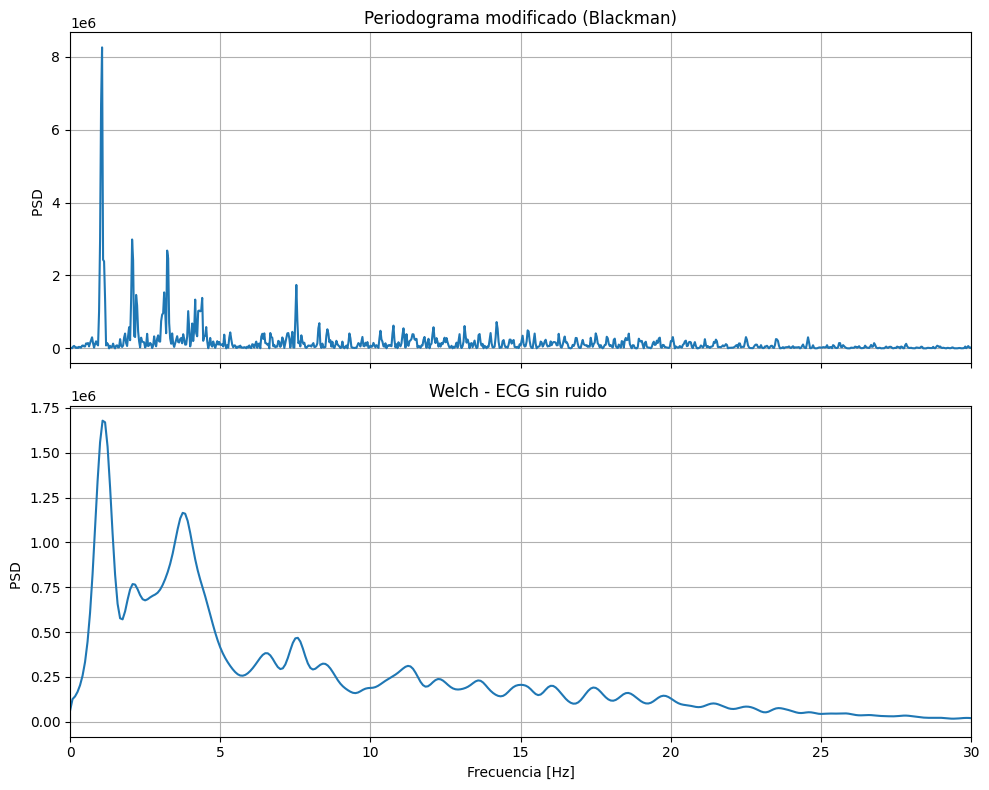

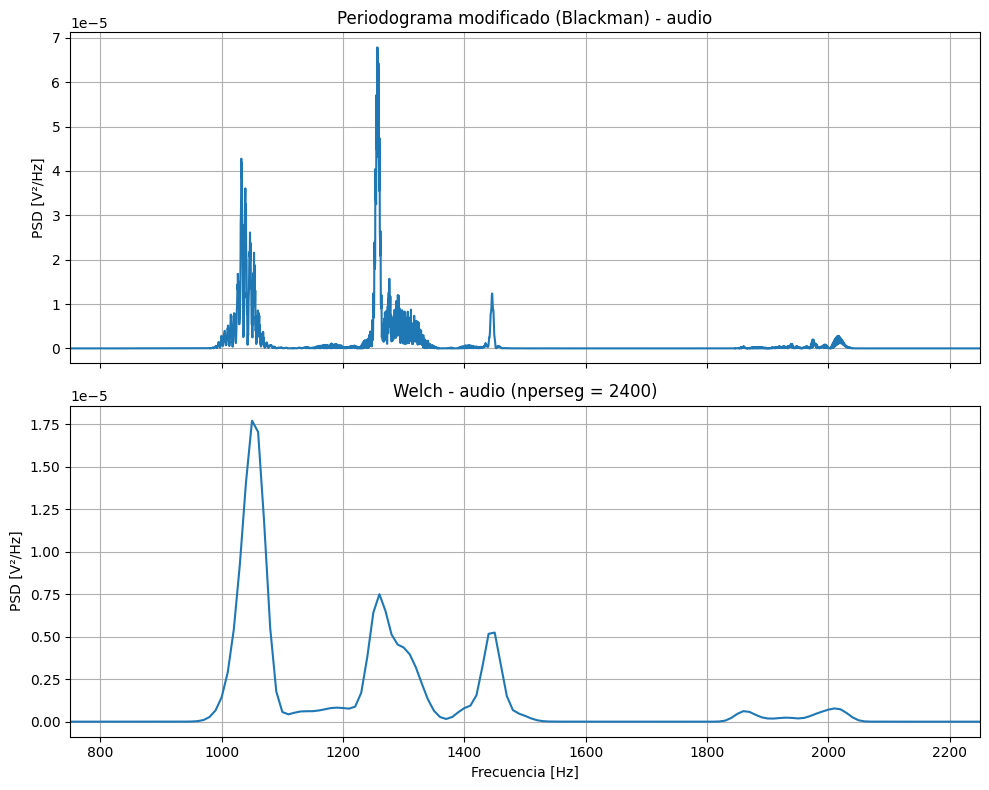

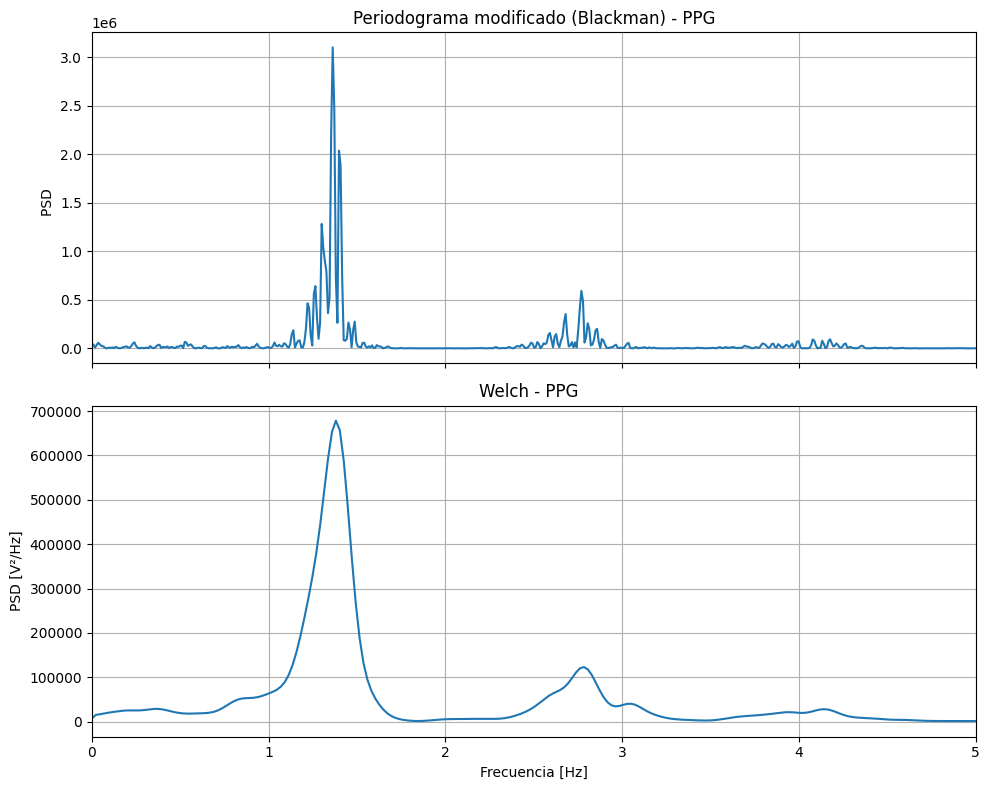

In [4]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io import wavfile      # necesario para que sio.wavfile exista en algunas versiones

 

#%% Lectura de ECG sin ruido
fs_ecg = 1000  # Hz

x = np.load('ecg_sin_ruido.npy').flatten()
x = x - np.mean(x)                 # media nula (asumida)

#%% Referencia: varianza = potencia
P_var = np.var(x)

#%% Periodograma modificado



f_p, Pxx = sig.periodogram(x, fs=fs_ecg, window='blackman' )
 

#%% Welch 

cant_Promedio = 10

nperseg = x.shape[0] // cant_Promedio #Longitud / cantidad de promedios

nfft = 4 * nperseg # ZeroPadding

window = 'blackman'
f_w, Pxx_w = sig.welch( x, fs=fs_ecg, window = window  , nperseg=nperseg, nfft= nfft )



#%% Area

 #np.cumsum() 
 
 
#%% Gráficos (dos subplots en una ventana)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(f_p, Pxx)
ax1.set_ylabel('PSD  ')
ax1.set_title('Periodograma modificado (Blackman)')
ax1.set_xlim(0, 30)
ax1.grid()

ax2.plot(f_w, Pxx_w)
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD  ')
ax2.set_title(f'Welch - ECG sin ruido ')
ax2.grid()

fig.tight_layout()
plt.show()


#%% AUDIO

 
fs_audio, x_audio = sio.wavfile.read('la cucaracha.wav')
 
#%% Periodograma modificado



f_audio, Pxx_audio = sig.periodogram(x_audio, fs=fs_audio, window='blackman' )
 

#%% Welch 

cant_Promedio = 60

nperseg = x_audio.shape[0] // cant_Promedio #Longitud / cantidad de promedios

nfft = 2 * nperseg # ZeroPadding

window = 'blackman'
f_a, Pxx_a = sig.welch( x_audio, fs=fs_audio, window='blackman', nperseg=nperseg, nfft= nfft )

 

#%% Gráficos (dos subplots en una ventana)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(f_audio, Pxx_audio)
ax1.set_ylabel('PSD [V²/Hz]')
ax1.set_title('Periodograma modificado (Blackman) - audio')
ax1.set_xlim(750, 2250)
ax1.grid()

ax2.plot(f_a, Pxx_a)
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [V²/Hz]')
ax2.set_title(f'Welch - audio (nperseg = {nperseg})')
ax2.grid()

fig.tight_layout()
plt.show()
 
#%% PPG sin ruido
 

fs_ppg = 400 # Hz

x_ppg = np.load('ppg_sin_ruido.npy')


#%% Periodograma modificado

f_p_ppg, Pxx_p_ppg = sig.periodogram(x_ppg, fs=fs_ppg, window='blackman')

#%% Welch

cant_Promedio = 10
nperseg = x_ppg.shape[0] // cant_Promedio   # longitud / cantidad de promedios
nfft = 4 * nperseg                          # zero padding

f_w_ppg, Pxx_w_ppg = sig.welch( x_ppg, fs=fs_ppg, window='blackman', nperseg=nperseg, nfft=nfft)

#%% Gráficos (dos subplots en una ventana)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(f_p_ppg, Pxx_p_ppg)
ax1.set_ylabel('PSD  ')
ax1.set_title('Periodograma modificado (Blackman) - PPG')
ax1.set_xlim(0, 5)
ax1.grid()

ax2.plot(f_w_ppg, Pxx_w_ppg)
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [V²/Hz]')
ax2.set_title(f'Welch - PPG  ')
ax2.grid()

fig.tight_layout()
plt.show()



In [8]:
#%% Ancho de banda (potencia acumulada, Welch)

# ECG
P_acum_ecg = np.cumsum(Pxx_w) / np.sum(Pxx_w)
bw_ecg_95 = f_w[np.where(P_acum_ecg >= 0.95)[0][0]]
bw_ecg_99 = f_w[np.where(P_acum_ecg >= 0.99)[0][0]]

# Audio
P_acum_audio = np.cumsum(Pxx_a) / np.sum(Pxx_a)
bw_audio_95 = f_a[np.where(P_acum_audio >= 0.95)[0][0]]
bw_audio_99 = f_a[np.where(P_acum_audio >= 0.99)[0][0]]

# PPG
P_acum_ppg = np.cumsum(Pxx_w_ppg) / np.sum(Pxx_w_ppg)
bw_ppg_95 = f_w_ppg[np.where(P_acum_ppg >= 0.95)[0][0]]
bw_ppg_99 = f_w_ppg[np.where(P_acum_ppg >= 0.99)[0][0]]

#%% Tabla
print("Señal  | BW 95 % [Hz] | BW 99 % [Hz]")
print("-------|--------------|-------------")
print(f"ECG    | {bw_ecg_95:12.2f} | {bw_ecg_99:12.2f}")
print(f"Audio  | {bw_audio_95:12.2f} | {bw_audio_99:12.2f}")
print(f"PPG    | {bw_ppg_95:12.2f} | {bw_ppg_99:12.2f}")

Señal  | BW 95 % [Hz] | BW 99 % [Hz]
-------|--------------|-------------
ECG    |        22.50 |        30.42
Audio  |      1500.00 |      2010.00
PPG    |         3.94 |         5.34


# Conclusiones

Se estimó el ancho de banda de cada señal como la frecuencia por debajo de la cual se concentra el 95 % y el 99 % de la potencia total, usando la suma acumulada de la PSD estimada con el método de Welch.

Los anchos de banda difieren según el origen de cada señal. El **PPG** es la de menor ancho de banda (≈ 4 Hz al 95 %): su potencia se concentra en la frecuencia cardíaca (cercana a 1,5 Hz) y en unos pocos armónicos. El **ECG** tiene un ancho de banda mayor (≈ 22.5 Hz al 95 %),  su contenido espectral se extiende a frecuencias más altas que la onda de pulso. El **audio**  es la de mayor ancho de banda (≈ 1.5 kHz al 95 %)

El ancho de banda depende del criterio elegido (porcentaje de potencia) y de los parámetros del estimador. La resolución de Welch es aproximadamente $f_s/L$, por lo que los valores reportados tienen una incertidumbre de ese orden. Además, se trabajó con señales sin ruido; en señales ruidosas el ruido de banda ancha aportaría potencia a frecuencias altas y aumentaría el ancho de banda estimado, sobre todo con el criterio del 99 %.

Para la visualización y selección de los parámetros del estimador de Welch se utilizo conjuntamente el periodograma y el método de Welch, aprovechando sus características complementarias. El periodograma permite observar con mayor detalle la estructura espectral, mientras que Welch reduce la varianza de la estimación mediante el promediado de periodogramas de segmentos. Se incrementó el número de promedios buscando obtener una PSD suave, procurando conservar el centro de masa de la señal. 